In [3]:
from datasets import load_dataset
ds = load_dataset("imagefolder", data_dir="/kaggle/input/datasets/suyashkumarbhagat/vedic-sanskrit-dataset/output/hf_dataset", drop_labels=True)
# ds["train"] → 539 examples, ds["val"] → 59, ds["test"] → 83

Resolving data files:   0%|          | 0/540 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/60 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/84 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [22]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers>=4.37", "datasets", "evaluate",
                "jiwer", "torchvision", "accelerate",
                "matplotlib", "seaborn", "pandas"], check=True)
print("Done")
 


Done


In [16]:
import os, torch, numpy as np
 
os.environ["CUDA_VISIBLE_DEVICES"]    = "0,1"
os.environ["TOKENIZERS_PARALLELISM"]  = "false"
 
n_gpus = torch.cuda.device_count()
print(f"GPUs: {n_gpus}")
for i in range(n_gpus):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name}  {p.total_memory // 1024**2} MB")
 
assert n_gpus >= 1
 
PER_DEVICE_BATCH = 7                         # 8 x 2 GPUs = 16 effective
EFFECTIVE_BATCH  = PER_DEVICE_BATCH * n_gpus
MAX_LEN          = 128
DATA_DIR   = "/kaggle/input/datasets/suyashkumarbhagat/vedic-sanskrit-dataset/output/hf_dataset"
OUTPUT_DIR = "/kaggle/working/trocr-sanskrit"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
print(f"Effective batch size : {EFFECTIVE_BATCH}")


GPUs: 2
  GPU 0: Tesla T4  14912 MB
  GPU 1: Tesla T4  14912 MB
Effective batch size : 14


In [17]:
from transformers import TrOCRProcessor
from torch.utils.data import Dataset
import torchvision.transforms as T
 
PROCESSOR = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
 
AUGMENT = T.Compose([
    T.RandomRotation(degrees=1.5, fill=255),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8)),
    T.RandomAffine(degrees=0, translate=(0.01, 0.005), fill=255),
])
 
class SanskritOCRDataset(Dataset):
    def __init__(self, hf_split, augment=False):
        self.data    = hf_split
        self.augment = augment
 
    def __len__(self):
        return len(self.data)
 
    def __getitem__(self, idx):
        item  = self.data[idx]
        image = item["image"].convert("RGB")
        if self.augment:
            image = AUGMENT(image)
 
        pixel_values = PROCESSOR(
            images=image, return_tensors="pt"
        ).pixel_values.squeeze(0)
 
        enc = PROCESSOR.tokenizer(
            item["text"],
            padding="max_length",
            max_length=MAX_LEN,
            truncation=True,
            return_tensors="pt",
        )
        labels = enc.input_ids.squeeze(0).clone()
        labels[labels == PROCESSOR.tokenizer.pad_token_id] = -100
 
        return {"pixel_values": pixel_values, "labels": labels}
 
val_key = "val" if "val" in ds else "validation"
 
train_dataset = SanskritOCRDataset(ds["train"], augment=True)
val_dataset   = SanskritOCRDataset(ds[val_key],  augment=False)
test_dataset  = SanskritOCRDataset(ds["test"],   augment=False)
 
s = train_dataset[0]
print(f"Train {len(train_dataset)} | Val {len(val_dataset)} | Test {len(test_dataset)}")
print(f"pixel_values: {s['pixel_values'].shape}  labels: {s['labels'].shape}")

Train 539 | Val 59 | Test 83
pixel_values: torch.Size([3, 384, 384])  labels: torch.Size([128])


In [18]:
from transformers import VisionEncoderDecoderModel
 
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")
 
model.config.decoder_start_token_id = PROCESSOR.tokenizer.cls_token_id
model.config.pad_token_id           = PROCESSOR.tokenizer.pad_token_id
model.config.eos_token_id           = PROCESSOR.tokenizer.sep_token_id
model.config.vocab_size             = model.config.decoder.vocab_size
model.config.max_length             = MAX_LEN
model.config.early_stopping         = True
model.config.no_repeat_ngram_size   = 3
model.config.length_penalty         = 2.0
model.config.num_beams              = 4
 
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params:     333,921,792
Trainable params: 333,921,792


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 5 (FIXED) — model setup
# ════════════════════════════════════════════════════════════════════════════
from transformers import VisionEncoderDecoderModel, GenerationConfig

model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

# --- required decoder config (these stay on model.config) -----------------
model.config.decoder_start_token_id = PROCESSOR.tokenizer.cls_token_id
model.config.pad_token_id           = PROCESSOR.tokenizer.pad_token_id
model.config.eos_token_id           = PROCESSOR.tokenizer.sep_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

# --- generation params go on model.generation_config, NOT model.config ----
# (transformers 4.40+ raises ValueError if you put them on model.config)
model.generation_config = GenerationConfig(
    max_length             = MAX_LEN,
    early_stopping         = True,
    num_beams              = 4,
    length_penalty         = 2.0,
    no_repeat_ngram_size   = 3,
    decoder_start_token_id = PROCESSOR.tokenizer.cls_token_id,
    pad_token_id           = PROCESSOR.tokenizer.pad_token_id,
    eos_token_id           = PROCESSOR.tokenizer.sep_token_id,
)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print(f"Generation config: {model.generation_config}")

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params    : 333,921,792
Trainable params: 333,921,792
Generation config: GenerationConfig {
  "decoder_start_token_id": 0,
  "early_stopping": true,
  "eos_token_id": 2,
  "length_penalty": 2.0,
  "max_length": 128,
  "no_repeat_ngram_size": 3,
  "num_beams": 4,
  "pad_token_id": 1
}



In [20]:
# ════════════════════════════════════════════════════════════════════════════
# CELL 7 (FIXED v2) — training arguments + trainer
# ════════════════════════════════════════════════════════════════════════════
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

steps_per_epoch = len(train_dataset) // EFFECTIVE_BATCH
total_steps     = steps_per_epoch * 50
warmup_steps    = max(1, int(total_steps * 0.1))

training_args = Seq2SeqTrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 50,
    per_device_train_batch_size = PER_DEVICE_BATCH,
    per_device_eval_batch_size  = PER_DEVICE_BATCH,

    dataloader_num_workers      = 4,
    dataloader_pin_memory       = True,
    ddp_find_unused_parameters  = False,

    fp16                        = True,
    gradient_accumulation_steps = 2,

    learning_rate               = 5e-5,
    lr_scheduler_type           = "cosine",
    warmup_steps                = warmup_steps,
    weight_decay                = 0.01,

    predict_with_generate       = True,
    generation_max_length       = MAX_LEN,

    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "cer",
    greater_is_better           = False,

    logging_steps               = steps_per_epoch,
    save_total_limit            = 3,
    report_to                   = "none",
    seed                        = 42,
)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    compute_metrics = compute_metrics,
    # tokenizer argument removed — deprecated in transformers 4.46+
)

print(f"Steps/epoch  : {steps_per_epoch}")
print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")
print(f"Est. time    : ~{total_steps * 1.8 / 60:.0f} min on 2xT4")

Steps/epoch  : 38
Total steps  : 1900
Warmup steps : 190
Est. time    : ~57 min on 2xT4


In [23]:
import time, pandas as pd
 
print("Starting training ...")
t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0
 
print(f"\nTraining complete in {elapsed/60:.1f} minutes")
print(f"Final train loss : {train_result.training_loss:.4f}")
 
trainer.save_model(f"{OUTPUT_DIR}/best_model")
PROCESSOR.save_pretrained(f"{OUTPUT_DIR}/best_model")
print(f"Best model saved to {OUTPUT_DIR}/best_model")
 
pd.DataFrame(trainer.state.log_history).to_csv(
    f"{OUTPUT_DIR}/training_log.csv", index=False
)
 

Starting training ...


Epoch,Training Loss,Validation Loss,Cer,Wer
1,No log,5.403333,2.849200,3.817600
2,32.708188,3.016870,1.547500,1.663700
3,32.708188,2.369403,0.793800,0.999000
4,9.998849,2.215308,0.727100,0.999000
5,9.998849,1.817734,0.709600,0.981400
6,7.831696,1.777503,0.700600,1.028400
7,7.831696,1.688456,0.715300,0.986300
8,6.844684,1.696762,0.726300,0.976500
9,6.844684,1.613108,0.699200,0.991200
10,6.437052,1.545947,0.716700,0.987300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.output_projection.weight'].



Training complete in 95.0 minutes
Final train loss : 4.2036


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to /kaggle/working/trocr-sanskrit/best_model


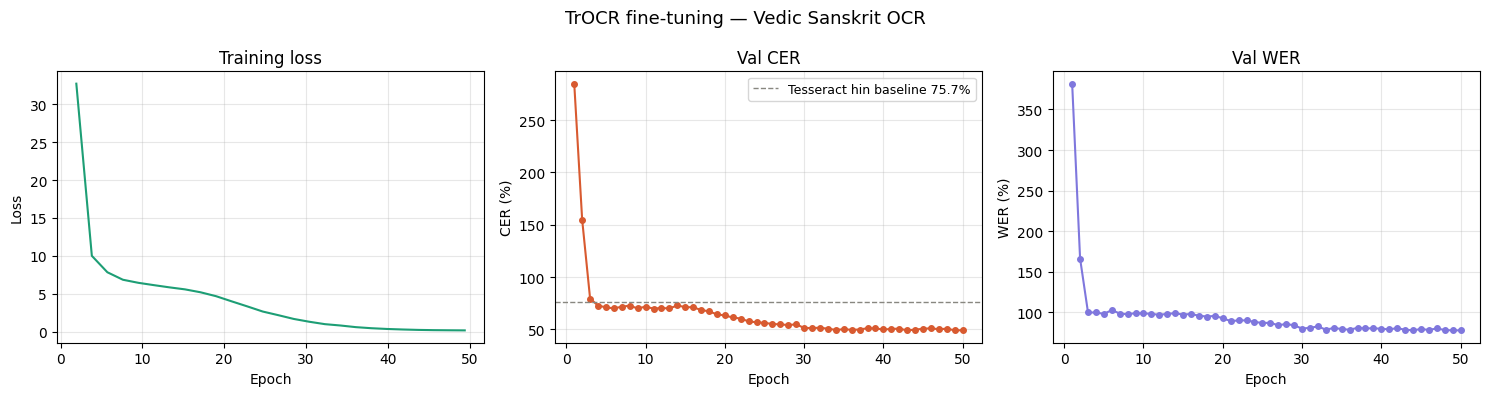

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
 
log_df    = pd.read_csv(f"{OUTPUT_DIR}/training_log.csv")
train_log = log_df[log_df["loss"].notna()].copy()
eval_log  = log_df[log_df["eval_cer"].notna()].copy()
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("TrOCR fine-tuning — Vedic Sanskrit OCR", fontsize=13)
 
axes[0].plot(train_log["epoch"], train_log["loss"], color="#1D9E75", lw=1.5)
axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)
 
axes[1].plot(eval_log["epoch"], eval_log["eval_cer"] * 100,
             color="#D85A30", lw=1.5, marker="o", ms=4)
axes[1].axhline(75.74, color="#888780", lw=1, ls="--",
                label="Tesseract hin baseline 75.7%")
axes[1].set_title("Val CER"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("CER (%)"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
 
axes[2].plot(eval_log["epoch"], eval_log["eval_wer"] * 100,
             color="#7F77DD", lw=1.5, marker="o", ms=4)
axes[2].set_title("Val WER"); axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("WER (%)"); axes[2].grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [25]:
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
import torch, pandas as pd
 
best_model = VisionEncoderDecoderModel.from_pretrained(f"{OUTPUT_DIR}/best_model")
best_proc  = TrOCRProcessor.from_pretrained(f"{OUTPUT_DIR}/best_model")
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model = best_model.to(device).eval()
 
INFER_BATCH = 16
test_raw    = ds["test"]
all_preds   = []
all_refs    = []
 
for i in range(0, len(test_raw), INFER_BATCH):
    batch  = test_raw[i : i + INFER_BATCH]
    images = [img.convert("RGB") for img in batch["image"]]
    pvals  = best_proc(images=images, return_tensors="pt").pixel_values.to(device)
    with torch.no_grad():
        gen = best_model.generate(
            pvals, num_beams=4, max_length=MAX_LEN, early_stopping=True
        )
    preds = best_proc.batch_decode(gen, skip_special_tokens=True)
    all_preds.extend(preds)
    all_refs.extend(batch["text"])
    print(f"  {min(i + INFER_BATCH, len(test_raw))}/{len(test_raw)}", end="\r")
 
def edit_distance(a, b):
    m, n = len(a), len(b)
    if m == 0: return n
    if n == 0: return m
    prev = list(range(n + 1))
    for i in range(1, m + 1):
        curr = [i] + [0] * n
        for j in range(1, n + 1):
            curr[j] = (prev[j-1] if a[i-1]==b[j-1]
                       else 1 + min(curr[j-1], prev[j], prev[j-1]))
        prev = curr
    return prev[n]
 
rows = []
for ref, hyp in zip(all_refs, all_preds):
    ed  = edit_distance(ref, hyp)
    cer = ed / max(len(ref), 1)
    rows.append({
        "reference":      ref,
        "hypothesis":     hyp,
        "ref_len":        len(ref),
        "edit_dist":      ed,
        "cer":            round(cer, 4),
        "has_vedic_mark": ("\u1cd0" in ref or "\u0952" in ref),
    })
 
results_df = pd.DataFrame(rows)
results_df.to_csv(f"{OUTPUT_DIR}/test_results.csv", index=False, encoding="utf-8")
 
overall_cer = results_df["edit_dist"].sum() / results_df["ref_len"].sum()
print(f"\nOverall CER  : {overall_cer*100:.2f}%")
print(f"Mean line CER: {results_df['cer'].mean()*100:.2f}%")
print(f"Baseline was : 75.74% (Tesseract hin)")
print(f"Improvement  : {(0.7574 - overall_cer)*100:+.2f} pp")
 
 


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

  83/83
Overall CER  : 48.89%
Mean line CER: 48.76%
Baseline was : 75.74% (Tesseract hin)
Improvement  : +26.85 pp


/tmp/ipykernel_55/1702438877.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
/tmp/ipykernel_55/1702438877.py:32: UserWarning: Glyph 7376 (\N{VEDIC TONE KARSHANA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1702438877.py:32: UserWarning: Glyph 2386 (\N{DEVANAGARI STRESS SIGN ANUDATTA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_55/1702438877.py:32: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/tmp/ipykernel_55/1702438877.py:33: UserWarning: Glyph 7376 (\N{VEDIC TONE KARSHANA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/error_analysis.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_55/1702438877.py:33: UserWarning: Glyph 2386 (\N{DEVANAGARI STRESS SIGN ANUDATTA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTP

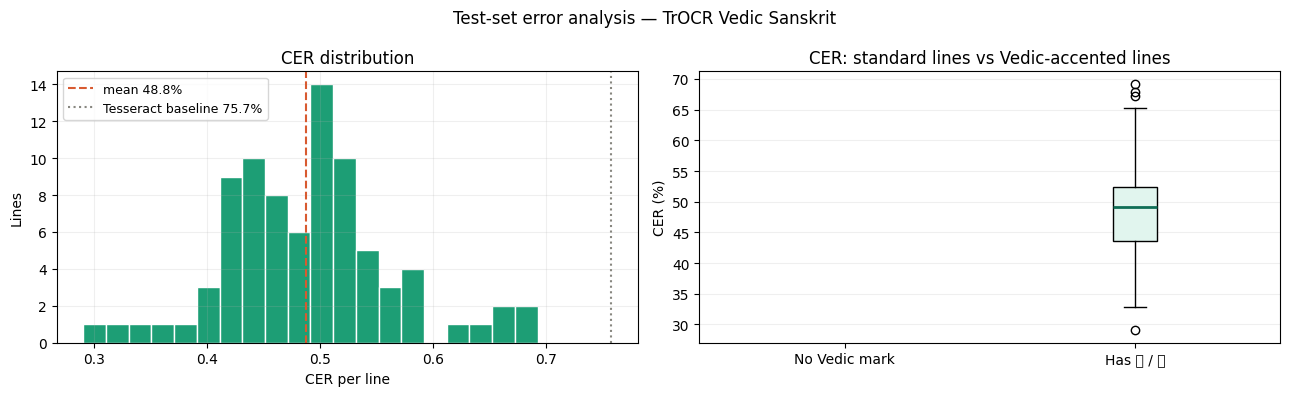

With Vedic mark  — mean CER: 48.76%  n=83
Without          — mean CER: nan%  n=0


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
 
results_df = pd.read_csv(f"{OUTPUT_DIR}/test_results.csv")
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Test-set error analysis — TrOCR Vedic Sanskrit", fontsize=12)
 
axes[0].hist(results_df["cer"], bins=20,
             color="#1D9E75", edgecolor="white", lw=0.5)
axes[0].axvline(results_df["cer"].mean(), color="#D85A30",
                lw=1.5, ls="--",
                label=f"mean {results_df['cer'].mean()*100:.1f}%")
axes[0].axvline(0.7574, color="#888780", lw=1.5, ls=":",
                label="Tesseract baseline 75.7%")
axes[0].set_xlabel("CER per line"); axes[0].set_ylabel("Lines")
axes[0].set_title("CER distribution"); axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)
 
vedic    = results_df[results_df["has_vedic_mark"]]["cer"]
no_vedic = results_df[~results_df["has_vedic_mark"]]["cer"]
axes[1].boxplot(
    [no_vedic * 100, vedic * 100],
    labels=["No Vedic mark", "Has \u1cd0 / \u0952"],
    patch_artist=True,
    boxprops=dict(facecolor="#E1F5EE"),
    medianprops=dict(color="#0F6E56", lw=2),
)
axes[1].set_ylabel("CER (%)")
axes[1].set_title("CER: standard lines vs Vedic-accented lines")
axes[1].grid(alpha=0.2, axis="y")
 
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"With Vedic mark  — mean CER: {vedic.mean()*100:.2f}%  n={len(vedic)}")
print(f"Without          — mean CER: {no_vedic.mean()*100:.2f}%  n={len(no_vedic)}")
 
 


In [27]:
import pandas as pd
 
results_df = pd.read_csv(f"{OUTPUT_DIR}/test_results.csv")
total = len(results_df)
 
print("── 10 WORST lines ─────────────────────────────────────────")
for _, r in results_df.nlargest(10, "cer").iterrows():
    print(f"  CER={r['cer']:.3f}")
    print(f"    REF: {r['reference']}")
    print(f"    HYP: {r['hypothesis']}\n")
 
print("── 10 BEST lines ──────────────────────────────────────────")
for _, r in results_df.nsmallest(10, "cer").iterrows():
    print(f"  CER={r['cer']:.3f}")
    print(f"    REF: {r['reference']}")
    print(f"    HYP: {r['hypothesis']}\n")
 
buckets = [
    ("Perfect  CER=0",    results_df["cer"] == 0.0),
    ("Good     CER<0.10", results_df["cer"] <  0.10),
    ("Fair     CER<0.30", results_df["cer"] <  0.30),
    ("Poor     CER<0.60", results_df["cer"] <  0.60),
    ("Failed   CER>=0.60",results_df["cer"] >= 0.60),
]
print("── CER buckets ─────────────────────────────────────────────")
for label, mask in buckets:
    n = mask.sum()
    print(f"  {label:<24s}  {n:3d}  ({n/total*100:.1f}%)")
 


── 10 WORST lines ─────────────────────────────────────────
  CER=0.692
    REF: त्वा जु॒ ष्ट त म मि॒ ति सा द य त्ये॒ ष वा॒ अ पा ᳰ र॒
    HYP: ग्री ज॒ रे तिः सो मे᳘ त॒ ᳰ पा प त य मः॒ं रि वृ ता ऽ ए षु द॒

  CER=0.679
    REF: हा॥७॥ सो॒ म ᳰ रा॒ जा नं॥ अ॒ व से ग्नि॒ म न्वा॒ र भा म हे
    HYP: हा म्।१८। सो॒ म ᳰ सा॒ं न्रु व रो गि मि॒ PayPal� न व्gpu ही मा

  CER=0.672
    REF: ती क्ष्णा ग्रो भ व ति। पि तृ दे व॒ त्यो वै ग॒ र्त्तः पि तृ लो
    HYP: ती पी॒ क्ष रो भ व ति तां प श द धि॒। अ य विः॒

  CER=0.652
    REF: जि॒ न ᳬ स्वा॒ हा॥९॥ अ॒ ग्ने ऽ अ॒ छा। व्व दे ह॒ नः प्र॒ ति नः सु म॒ ना
    HYP: स्वा॒ हा णुः।२। ऽ आ॒ ᳰ बृ हि व रे द॒तु न म्।ि॑ प निः सीः

  CER=0.647
    REF: सं॒ ᳬ स्पृ श ते त॒ दा त्म॒ न्कु रु ते त॒ स्मा द्गो धू॒ मा नु॒ ष स्पृ
    HYP: सा॒ ष्यु सू ता ते तं॒�ा नृ क्॑ क रुतै त जा जो हैं धा मु DEFENSE पृ

  CER=0.630
    REF: १२॥ त॒ ऽ उ भ॒ ये च॒ तु स्त्रि ᳰ श द्ग्र॒ हाः सं॒ प द्य न्ते त्र॒ य स्त्रि
    HYP: १। त॒ ऽ ए ष॒ ᳰ श्युं कृ सि रा गृ᳘ होः णं॒ः।९ ति॒  आ॒

  CER=0.583
    REF: हि स

In [28]:
import pandas as pd
 
results_df  = pd.read_csv(f"{OUTPUT_DIR}/test_results.csv")
overall_cer = results_df["edit_dist"].sum() / results_df["ref_len"].sum()
vedic_cer   = results_df[results_df["has_vedic_mark"]]["cer"].mean()
nov_cer     = results_df[~results_df["has_vedic_mark"]]["cer"].mean()
 
print(r"\begin{table}[h]")
print(r"\centering")
print(r"\begin{tabular}{lcccc}")
print(r"\hline")
print(r"Model & Setting & CER (\%) & CER$_{\text{plain}}$ & CER$_{\text{Vedic}}$ \\")
print(r"\hline")
print(r"Tesseract (san) & zero-shot & 77.71 & --- & --- \\")
print(r"Tesseract (hin) & zero-shot & 75.74 & --- & --- \\")
print(f"TrOCR-base-handwritten & fine-tuned & {overall_cer*100:.2f} & {nov_cer*100:.2f} & {vedic_cer*100:.2f} \\\\")
print(r"\hline")
print(r"\end{tabular}")
print(r"\caption{OCR results on the Vedic Sanskrit manuscript test set (83 lines, 5{,}338 characters). "
      r"CER$_{\text{plain}}$ excludes lines containing Vedic accent marks; "
      r"CER$_{\text{Vedic}}$ covers lines with \textit{uda\={a}tta}/\textit{anud\={a}tta} diacritics.}")
print(r"\label{tab:ocr_results}")
print(r"\end{table}")
 
 


\begin{table}[h]
\centering
\begin{tabular}{lcccc}
\hline
Model & Setting & CER (\%) & CER$_{\text{plain}}$ & CER$_{\text{Vedic}}$ \\
\hline
Tesseract (san) & zero-shot & 77.71 & --- & --- \\
Tesseract (hin) & zero-shot & 75.74 & --- & --- \\
TrOCR-base-handwritten & fine-tuned & 48.89 & nan & 48.76 \\
\hline
\end{tabular}
\caption{OCR results on the Vedic Sanskrit manuscript test set (83 lines, 5{,}338 characters). CER$_{\text{plain}}$ excludes lines containing Vedic accent marks; CER$_{\text{Vedic}}$ covers lines with \textit{uda\={a}tta}/\textit{anud\={a}tta} diacritics.}
\label{tab:ocr_results}
\end{table}


In [29]:
import os
 
files = [
    f"{OUTPUT_DIR}/best_model",
    f"{OUTPUT_DIR}/training_log.csv",
    f"{OUTPUT_DIR}/test_results.csv",
    f"{OUTPUT_DIR}/training_curves.png",
    f"{OUTPUT_DIR}/error_analysis.png",
]
 
print("Output artifacts:")
for path in files:
    if os.path.exists(path):
        if os.path.isdir(path):
            size = sum(
                os.path.getsize(os.path.join(r, f))
                for r, _, fs in os.walk(path) for f in fs
            )
            print(f"  OK  {path}/   ({size/1024**2:.1f} MB)")
        else:
            print(f"  OK  {path}   ({os.path.getsize(path)//1024} KB)")
    else:
        print(f"  MISSING  {path}")
 
print("\nAll done. Download from the Kaggle Output tab.")


Output artifacts:
  OK  /kaggle/working/trocr-sanskrit/best_model/   (1277.3 MB)
  OK  /kaggle/working/trocr-sanskrit/training_log.csv   (5 KB)
  OK  /kaggle/working/trocr-sanskrit/test_results.csv   (24 KB)
  OK  /kaggle/working/trocr-sanskrit/training_curves.png   (84 KB)
  OK  /kaggle/working/trocr-sanskrit/error_analysis.png   (65 KB)

All done. Download from the Kaggle Output tab.
